##  STEP 0: Importazione del Dataset e Connessione all'Ambiente

### 0.1 Montaggio di Google Drive
Con questo blocco di codice collego il notebook di Google Colab al mio account di Google Drive. In questo modo consento all'ambiente di accedere ai file salvati nelle cartelle remote, incluso il dataset del progetto.

In [1]:
from google.colab import drive
drive.mount('/content/drive/') #monto drive google personale nel filesystem della vm di colab

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### 0.2 Verifica dei file nel percorso di progetto
Eseguo da terminale (`!ls`) per ispezionare il contenuto della cartella `Progetto_DNN`. Questo permette di verificare visivamente che il file del dataset (`MSFT_Stock.xls`) e altri file utili siano effettivamente presenti nel percorso specificato prima di procedere al caricamento.

In [2]:
# Verifico percorso e presenza dei file
!ls /content/drive/MyDrive/'Colab Notebooks'/Progetto_DNN


main.ipynb  MSFT_Stock.xls


## STEP 1: Studio del Dataset e Creazione del DataFrame

Svolgo le prime operazioni di **Analisi Esplorativa dei Dati (EDA)** e la preparazione dell'ambiente di lavoro:

1. **Importazione delle Librerie:**
   * `pandas` e `numpy` per la manipolazione dei dati e dei vettori.
   * `matplotlib` per la creazione dei grafici.
   * `scikit-learn` per le metriche di errore (MSE, MAE) e la riscalatura dei dati.
   * `torch` e `torch.nn` (**PyTorch**) per la futura costruzione, definizione ed addestramento delle reti neurali.
2. **Caricamento e Pulizia Temporale:**
   * Leggo il file `MSFT_Stock.xls` e imposto la data come indice del DataFrame.
   * Convertiamo l'indice nel formato di data standard `datetime` e ordiniamo il DataFrame dal giorno più vecchio al più recente.
3. **Ispezione delle Caratteristiche:**
   * Stampo le dimensioni del dataset (righe e colonne) e il range temporale coperto.
   * Verifico l'eventuale presenza di dati mancanti o valori nulli (`isnull`).
   * Visualizzo le prime 5 righe e le statistiche descrittive principali (media, deviazione standard, min/max) del prezzo di chiusura (*Close Price*).
4. **Visualizzazione Grafica:**
   * Traccio il grafico dell'andamento storico del prezzo di chiusura di Microsoft per identificare a colpo d'occhio il trend e la volatilità nell'arco degli anni.

ISPEZIONE DATASET
Dimensioni dataset: 5000 righe, 5 colonne
Intervallo temporale: da 2001-03-16 a 2021-01-29
Valori nulli/mancanti:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Prime 5 righe:


,open,high,low,close,volume
2001-03-16,26.25000,27.56250,26.24219,27.28125,112848800
2001-03-19,27.25000,27.75000,26.56250,27.15625,61036400
2001-03-20,27.28125,28.06250,26.31250,26.34375,91822800
2001-03-21,26.12500,26.62500,24.87500,25.03125,124988600
2001-03-22,25.28125,27.03125,25.25000,27.00000,126363200



Statistiche descrittive (Close Price):


,close
count,5000.000000
mean,50.926300
std,44.823724
min,15.150000
25%,26.578750
50%,29.920000
75%,52.162500
max,238.929990


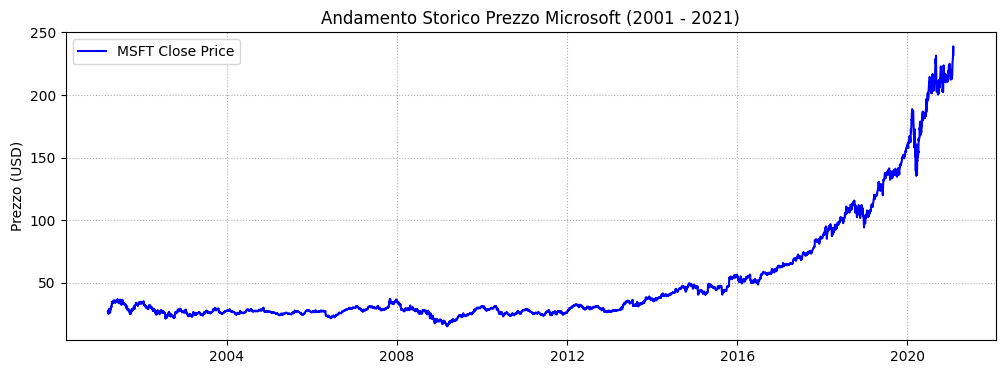

In [3]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdb #importo debug
#pdb.set_trace() : per usare il debug python

#  Caricamento Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Progetto_DNN/MSFT_Stock.xls', index_col=0) #dataframe(tabella) e uso laprima colonna come indice riga
df.index = pd.to_datetime(df.index) #converto stringhe delle date in formato datetime64(ogetto data/ora), posso fare resampling
df.sort_index(inplace=True) #ordino le righe cronologicamente su df (non creo copie)

print("ISPEZIONE DATASET")
print(f"Dimensioni dataset: {df.shape[0]} righe, {df.shape[1]} colonne") #df.shape da una tupla(5000,5); shape[0] estrae righe,shape[1] estrae colonne
print(f"Intervallo temporale: da {df.index.min().date()} a {df.index.max().date()}") #estraggo data iniziale e finale
print(f"Valori nulli/mancanti:\n{df.isnull().sum()}\n") #verifico se ho valori nulli
print("Prime 5 righe:")
display(df.head()) # df.read estrae primi 5 valori della tab;display() me lo fa vedere come tabella html

print("\nStatistiche descrittive (Close Price):")
display(df[['close']].describe())

# Grafico del prezzo grezzo
plt.figure(figsize=(12, 4))
plt.plot(df['close'], color='blue', label='MSFT Close Price')
plt.title('Andamento Storico Prezzo Microsoft (2001 - 2021)')
plt.ylabel('Prezzo (USD)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()



  
## STEP 2: Preprocessing dei Dati e Creazione del Dataset Sequenziale

In questa fase trasformo la serie storica grezza in una struttura dati supervisionata adatta all'addestramento delle reti neurali in PyTorch.

1. **Normalizzazione Relativa alla Finestra**
   - Anziché utilizzare un *MinMaxScaler* globale, uso una normalizzazione locale: ciascuna finestra temporale viene divisa per il prezzo del suo primo giorno (baseline locale).
   - **Motivazione:** il prezzo di chiusura di Microsoft passa da ~15 $ (2001) a ~239 $ (2021). Uno scaler globale con statistiche fisse calcolate sul passato (2001–2015) produrrebbe nel Test Set (2018–2021) valori completamente fuori scala mai visti in training. La normalizzazione locale rende il problema **scala-invariante**.
   - **Assenza di Data Leakage:** la baseline è sempre e solo il primo elemento della finestra stessa (dato passato già consolidato e quindi non un valore futuro).

2. **Creazione delle Finestre Temporali (Sliding Window)**
   - Riduco la serie temporale a un problema di regressione supervisionata mediante una finestra scorrevole a passo unitario di ampiezza $N = 30$ giorni (circa 6 settimane di borsa aperta).
   - Per ogni finestra, i primi 29 giorni normalizzati ($x_1, \dots, x_{29}$) costituiscono il tensore delle feature di input $X$, mentre il 30-esimo giorno ($x_{30}$) rappresenta il target scalare $y$ da predire.

3. **Suddivisione Dataset (Train, Validation, Test Set)**
   - Suddivido il Dataset rispettando rigidamente la sequenza temporale per impedire qualsiasi contaminazione futura (*data leakage*):
     - **Training Set (70%):** anni 2001 – 2015 (3479 campioni).
     - **Validation Set (15%):** anni 2015 – 2018 (746 campioni).
     - **Test Set (15%):** anni 2018 – 2021 (746 campioni).

4. **Organizzazione in Mini-Batch e Gestione dello Shuffle**
   - **Dimensione del Batch (`BATCH_SIZE = 32`):** rappresenta il compromesso ottimale per l'ottimizzatore Adam. Un batch di 32 campioni offre una stima del gradiente sufficientemente stabile da guidare la discesa, ma introduce quel leggero rumore stocastico benefico che aiuta l'ottimizzazione a sfuggire da minimi locali poco profondi, mantenendo al contempo un'elevata efficienza computazionale in memoria GPU.
   - **Shuffle nel Training (`shuffle=True`):** ad ogni epoca mescola l'ordine di presentazione dei chunk (finestre) tra loro. Poiché finestre consecutive create con sliding window condividono il 97% dei dati (28 giorni su 29), lasciarle in ordine sequenziale produrrebbe batch con gradienti quasi identici e fortemente polarizzati sul trend locale di un singolo mese. Lo shuffle raggruppa nello stesso batch finestre provenienti da anni e regimi di mercato differenti (es. 2003, 2008, 2013), **rompendo l'autocorrelazione seriale, riducendo l'overfitting e massimizzando la capacità di generalizzazione** del modello.
   - **Nessuno Shuffle in Validazione e Test (`shuffle=False`):** l'ordine sequenziale viene mantenuto rigorosamente sia per garantire una valutazione deterministica dell'Early Stopping, sia per consentire la corretta ricostruzione cronologica della serie temporale nella fase di predizione visiva finale.

In [4]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import random

# FUNZIONE PER FISSARE IL SEED : PER AVERE GLI STESSI RISULTATI QUANDO RIESCESEGUO IL NOTEBOOK
def set_seed(seed=42):
    """Fissa il seed per la riproducibilità dei risultati"""
    random.seed(seed)
    np.random.seed(seed) #blocco generatore causale di python
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed) #invio seed a gpu nvidia se presente
    torch.backends.cudnn.deterministic = True # uso alg det
    torch.backends.cudnn.benchmark = False #



# Impostiamo il device (GPU se disponibile, altrimenti CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

# STEP 1: PREPROCESSING CON SLIDING WINDOW (NUMPY)
# uso 'df' preparato e ordinato nello STEP 1
data = df["close"].values  # Estraggo un array numpy unidimensionale con i 5000 valori della colonna
N = 30  # Finestra di 30 giorni (29 input + 1 target)

X_list, y_list, baselines = [], [], []
for i in range(len(data) - N + 1): #faccio scorrere in avanti la finestra un giorno alla volta (4971 finestre)
    chunk = data[i : i + N]  # 30 elementi consecutivi
    base_price = chunk[0]  # Primo prezzo della finestra (giorno 1)

    # Normalizzazione locale per chunk
    normalized_chunk = chunk / base_price #ogni valore viene espresso in rapporto al prezzo iniziale; il primo valore sarà 1.0

    X_list.append(normalized_chunk[:-1])  # Primi 29 giorni (input)
    y_list.append(normalized_chunk[-1])  # Ultimo giorno (target)
    baselines.append(base_price) #salvo il prezzo del primo giorno di ogni sequenza

#X_list è una matrice di liste, la trasformo in una matrice 2D (campioni,29) e poi in un tensore (campioni,29,1)
# le LSTM,CNN1D richiedono 3 dimensioni in input
# Creazione MATRICI NUMPY
X = np.array(X_list)[..., np.newaxis]  # Shape: (Campioni, 29, 1)
y = np.array(y_list)  # Shape: (Campioni,) , Y rimane un vettore colonna per la regressione
baselines = np.array(baselines)
#print(X[0])


# Split Temporale (70% Train, 15% Val, 15% Test)
total = len(X)
train_end = int(total * 0.70)
val_end = int(total * 0.85)

X_train_np, y_train_np = X[:train_end], y[:train_end]
X_val_np, y_val_np = X[train_end:val_end], y[train_end:val_end]
X_test_np, y_test_np = X[val_end:], y[val_end:]

# Dati per la ricostruzione dei prezzi reali in $ sul Test set
baselines_test = baselines[val_end:]
y_test_real = y_test_np * baselines_test


# STEP 2: CONVERSIONE IN TENSORI PYTORCH
# .unsqueeze(1) porta y da shape (N,) a (N, 1) per combaciare con l'output della rete
X_train = torch.tensor(X_train_np, dtype=torch.float32) #converto in tensore
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1) #stessa dimensione output rete (batch_size,1)

X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)


# STEP 3: CREAZIONE DEI DATALOADER PYTORCH
BATCH_SIZE = 32

#creo dataset : associo x->y in copie(input,target)
train_dataset = TensorDataset(X_train, y_train) #unisico 2 tensori, ogni indice mi da una tupla
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# shuffle=False per non rompere l'ordine sequenziale delle serie storiche
#DATALOADER: prende il dataset, e divide in batch

#mescolo i chunck tra loro, riduco correlazione dati input per migliorare train con sgd
#durante il train ad ogni epoca cambia l'ordine dei chunck  (mescolo i singoli campioni)
#nel train ogni chunk non condivide i giorni con altri chunk
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #mescolo i cunkc tra loro

# shuffle=False perchè in validation devo monitorare la loss e decidere in modo deterministico l'early stop.
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# STEP 4: VERIFICA FINALE
print("ISPEZIONE SHAPE E DATALOADER ")
print(f"Shape X_train Tensor: {X_train.shape}")
print(f"Shape y_train Tensor: {y_train.shape}")
print(f"Batch nel train_loader: {len(train_loader)}")
print(f"Batch nel val_loader:   {len(val_loader)}")
print(f"Batch nel test_loader:  {len(test_loader)}")

Dispositivo in uso: cuda
ISPEZIONE SHAPE E DATALOADER 
Shape X_train Tensor: torch.Size([3479, 29, 1])
Shape y_train Tensor: torch.Size([3479, 1])
Batch nel train_loader: 109
Batch nel val_loader:   24
Batch nel test_loader:  24


## STEP 3: Definizione e Costruzione del Modelli

Definisco la struttura della Rete Neurale utilizzando la libreria **TensorFlow / Keras**:

1. **Architettura della Rete**:
   - Definisco una struttura sequenziale (`Sequential`).
   - Aggiungo i livelli ricorrenti (es. `LSTM` o `GRU`) o livelli densi (`Dense`) in grado di catturare le dipendenze temporali del prezzo.
   - Aggiungo i livelli di `Dropout` per prevenire l'overfitting (evitando che la rete memorizzi troppo i dati di training).
   - Inserisco il livello finale di output con un singolo neurone per la predizione del valore numerico continuo.

2. **Compilazione**:
   - **Funzione di Loss**: Utilizzo il Mean Squared Error (`MSE`) per misurare la distanza tra i valori predetti e quelli reali.
   - **Ottimizzatore**: Utilizzo `Adam` per l'aggiornamento efficiente dei pesi.



In [5]:

import torch.nn as nn

# MLP
class PyTorchMLP(nn.Module):
    def __init__(self): #self instanza corrente della classe
        super().__init__() #costruttore della superclasse nn.Module
        self.flatten = nn.Flatten() #lascia intantta dim batch e appiatisce le altre (32,29,2)->(32,29)
        self.fc1 = nn.Linear(29, 64) #AUMENTO SPAZIO LATENTE:espando info dei 29 giorni su 64 neuroni
        self.relu = nn.ReLU() #applico RELU
        self.drop = nn.Dropout(0.2)  #droputo 20% dei neuroni;riduco overfitting
        self.fc2 = nn.Linear(64, 32) #RIDUCO SPAZIO LATENTE:comprimo info su 32 neuroni
        self.out = nn.Linear(32, 1) #layer out:1 valore scalare

    def forward(self, x): #def propagazione in avanti
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.relu(self.fc2(x))
        return self.out(x)

# 1D-CNN
class PyTorchCNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3) # 32 filtri/kernel differenti, ogni kernel osserva 3 giorni consecutivi
                                                                              # stride=1, no padding
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2) #downsampling prendendo 2 valori consecutivi e prendo il max; Conv1D(29): 27 -> MaxPool1D(2): 13.
        self.flatten = nn.Flatten() #converto  le 32 feature map in un vettore piatto. Ho Feature map totali: 32 * 13 = 416
        self.fc1 = nn.Linear(32 * 13, 32) #LAYER FULLy-CONNECTED 416 feature -> 32 neuroni
        self.out = nn.Linear(32, 1) #scalare out

    def forward(self, x):
        # Ingresso dal DataLoader: (batch_size=32, seq_len=29, channels=1)
        x = x.transpose(1, 2)
        # (32, 1, 29) -> (batch, channels, seq_len); converto le dimensione per essere compatibile con la classe cnn1d
        # CONV + RELU :(32, 32, 27)
        x = self.relu(self.conv1(x))
        #MAXPOOL :(32, 32, 13)
        x = self.pool(x)
        # FLATTEN :(32, 416)
        x = self.flatten(x)
        # layer dense + relu: (32,32)
        x = self.relu(self.fc1(x))
        #out scalare
        return self.out(x)

# LSTM
class PyTorchLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # con batch_first=True lstm accetta formato (batch=32,seq_len=29,input_size=1), altrimenti dovrei avere(29,32,1)
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True) #dim vettori ht e ct =64;
        self.drop = nn.Dropout(0.2)
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        #lstm resitusce(output,(h_n,c_n))
        #lstm_out, _  non salvo il secondo valore della tupla perchè non mi serve
        lstm_out, _ = self.lstm(x) # contiene lo stato nascosto ht per tutti i 29 istanti da 64 el; out:(32,29,64)
        # caso many-to-one
        last_step = lstm_out[:, -1, :] # Prendo solo il vettore del giorno 29(l'ultimo); ho (32,64)
        x = self.drop(last_step)
        x = self.relu(self.fc1(x)) #(32,64) ->(32,32)
        return self.out(x) #out(32,1); 1 singolo prezzo predetto per ogniuno dei 32 campioni del batch

# GRU
class PyTorchGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=64, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        #gru restituisce (output,h_n), c_n non esiste
        gru_out, _ = self.gru(x) #(32,29,64)
        last_step = gru_out[:, -1, :] # Prendiamo solo l'ultimo stato temporale
        x = self.drop(last_step)
        x = self.relu(self.fc1(x))
        return self.out(x)

## STEP 4: Definizione del Ciclo di Training, Validation e Test

In questa fase definisco le due funzioni principali per l'addestramento e la valutazione di ciascuna architettura di rete neurale:

1. **`train_and_validate()` (Funzione di Addestramento e Validazione):**
   * **Setup:** Configura la funzione di perdita **MSE Loss** (`nn.MSELoss`) e l'ottimizzatore **Adam** (`torch.optim.Adam`).
   * **Fase di Training (`model.train()`):** Per ogni batch esegue il *Forward Pass*, calcola la loss, azzera i gradienti (`optimizer.zero_grad()`), calcola la *Backpropagation* (`loss.backward()`) e aggiorna i pesi (`optimizer.step()`).
   * **Fase di Validazione (`model.eval()`):** Disabilita il calcolo dei gradienti tramite `torch.no_grad()` per risparmiare memoria e calcolare le prestazioni del modello su dati non visti durante l'epoca.
   * **Maccanismo di Early Stopping:** Se la `val_loss` non migliora per un numero di epoche pari a `patience` (impostata a 10), l'addestramento si interrompe per evitare l'overfitting. Salva una copia profonda (`copy.deepcopy`) dei pesi del modello migliore e li ripristina alla fine.

2. **`test_loop()` (Funzione di Valutazione sul Test Set):**
   * Esegue la predizione in modalità *Inference* (`torch.no_grad()`) sul dataset di test.
   * **Denormalizzazione:** Moltiplica i valori predetti (normalizzati) per la *baseline* iniziale di ogni finestra temporale per ricostruire il prezzo reale stimato in dollari ($).
   * **Calcolo delle Metriche:**
     * **Metriche Assolute ($):** Calcola **RMSE** (Root Mean Squared Error) e **MAE** (Mean Absolute Error) sui prezzi reali in USD.
     * **Metriche Relative (%):** Calcola l'errore percentuale medio relativo al prezzo medio reale del periodo di test, offrendo un'interpretazione aziendale immediata.

In [6]:
import copy
import math
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error



# eseguo train,validation, early stop e ripristino pesi migliori
#IPERPARAMETRI: epochs=100 come valore di default,lr di Adam,patience(numero di epoche consecutive senza miglioramento val loss)
def train_and_validate(model, train_loader, val_loader, epochs=100, lr=0.0001, patience=10):
    model = model.to(device) #trasferisco parametri a GPU se presente,altrimenti CPU
    criterion = nn.MSELoss() # CALCOLO LOSS MSE
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #ADAM

    #questi vettori vengono usati per disegnare curve blu e ross per train/val
    history = {'loss': [], 'val_loss': []} #Dizionario che salva loss train e val per ogni epoca
    best_val_loss = float('inf') #loss validation migliore,primo valore infinito positivo
    patience_counter = 0 #epoche conseutive senza miglioramento,se arriva a 10 train si interrompe
    best_model_weights = None #pesi loss migliore
    best_epoch = 0 #salvo indice epoca migliore
    for epoch in range(epochs): #(EPOCA 0: TRAIN E VAL SUI BATCH , PEOCA 1:..... E RIPETO)
        # 1: TRAINING
        model.train() #attivo modalita train (attivo,serve come regolarizzazione)
        train_loss = 0.0 #ogni epoca resetto la loss
        for X_b, y_b in train_loader: #per ogni batch
            X_b, y_b = X_b.to(device), y_b.to(device)

            #pytorch accumula i gradienti nei tensori dei parametri
            optimizer.zero_grad() #azzero i gradienti vecchi (epoca precedente)
            preds = model(X_b).view(-1) #dati entrano nella rete e produco output; appiattisco output; X_b è il batch
            loss = criterion(preds.view(-1,1), y_b.view(-1,1)) #calcolo loss(confronto predizione con target reale) del batch
            loss.backward() # BACKPROPAGATION:calcolo gradienti batch corrente
            optimizer.step() #ADAM:aggiorno i pesi batch per ridurre loss

            #loss.item() * X_b.size(0) sommo loss media per il nuemro di campioni del batch
            train_loss += loss.item() * X_b.size(0) #sommo loss dei batch

        epoch_train_loss = train_loss / len(train_loader.dataset) #MSE sul singolo campione su tutto il trainset

        # 2: VALIDATION, procedura quasi identica al train, ma non modifico i pesi, uso quelli del train per verificare quanto il modello
        # generalizza su dati che non ha usato per aggiornare i parametri

        model.eval() #modalita evaluation(dropout disattivato)
        val_loss = 0.0 #riazzero loss precedente per calcolare quello attuale
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b).view(-1)
                loss = criterion(preds.view(-1,1), y_b.view(-1,1))
                val_loss += loss.item() * X_b.size(0) #sommo loss attuale

        epoch_val_loss = val_loss / len(val_loader.dataset) # loss per scelta modello e early stop

        #salvo e aggiungo in una lista le loss di ogni epoca;
        #uso questi valori per grafico train(blu) e val(rossa)
        history['loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        # Early Stopping
        if epoch_val_loss < best_val_loss: #se validation migliora
            best_val_loss = epoch_val_loss #aggiorno miglior loss
            patience_counter = 0 #azzero contatore
            best_model_weights = copy.deepcopy(model.state_dict()) #copio i pesi del modello che ha generalizzato meglio
            best_epoch = epoch #salvo indice epoca migliore

        else: #val loss non migliora
            patience_counter += 1
            if patience_counter >= patience:
                break #esco dal ciclo; blocco train mentre la genralizzazione peggiora; evito overfitting

    #dopo che il modello ha completato tutte le epoche masssime o si è feramto all'early stop
    # Fuori dal ciclo ripristino i pesi migliori ottenuti durante la validazione(es. esco a epoca 14 ma i pesi migliori erano di epoca 4,devo rispristinare i pesi di epoca 4)
    if best_model_weights is not None: #se salvo pesi migliori nella validation
        model.load_state_dict(best_model_weights) #sostituisco con i pesi migliori (ho un dizionario che contine tutti i tensori)

    # Aggiungo best_epoch:indice al dizionario
    history['best_epoch'] = best_epoch

    return history, model


# inferenza su test set,calcolo metriche MSE,RMSE,MAE
def test_loop(model, test_loader, y_te_real, baselines_te):
    # 3: TEST
    model.eval() #disattivo dropout
    preds_scaled = []

    with torch.no_grad(): #non calcolo gradienti
        for X_b, _ in test_loader:
            X_b = X_b.to(device)
            preds = model(X_b).view(-1) #do al modello e ottengo vettore out
            preds_scaled.extend(preds.cpu().numpy().tolist()) #aggiungo out alla lista predizioni

    # Denormalizzazione in Dollari ($)
    y_pred_real = np.array(preds_scaled) * baselines_te

    # Calcolo Metriche Finale in dollari
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = math.sqrt(mean_squared_error(y_te_real, y_pred_real))
    mae = mean_absolute_error(y_te_real, y_pred_real)

    # Metriche in Percentuale (%) rispetto al prezzo medio reale
    mean_price = np.mean(y_te_real) #prezzo medio realte testset
    mse_pct = (mse / (mean_price ** 2)) * 100 #MSE PERCENTUALE
    rmse_pct = (rmse / mean_price) * 100 #RMSE PERCENTUALE
    mae_pct = (mae / mean_price) * 100 #MAE PERCENTUALE

    return y_pred_real, mse, rmse, mae , mse_pct, rmse_pct, mae_pct






## STEP 5: Valutazione del Modello e Diagnostica

Analizzo l'andamento dell'apprendimento per assicurarmi che la rete abbia imparato correttamente senza andare in overfitting:

1. **Grafico della Loss (Training vs Validation)**:
   - Traccio la curva di errore per visualizzare l'andamento delle metriche epoch dopo epoch.
   - Verifico che la curva di validazione segua da vicino quella di training.

2. **Calcolo delle Metriche di Errore**:
   - Calcolo gli indici prestazionali quantitativi sul set di Test: **MSE** (Mean Squared Error), **RMSE** (Root Mean Squared Error) e **MAE** (Mean Absolute Error).

In [7]:
# Creo un dizionario per salvare i risultati di tutti i modelli,ogni chiave identifica un modello e valore i risultati
results = {}

MLP
Risultati MLP Test Set:
  • MSE:  47.46 (0.22%)
  • RMSE: $6.89  |  4.73%
  • MAE:  $4.72  |  3.24%


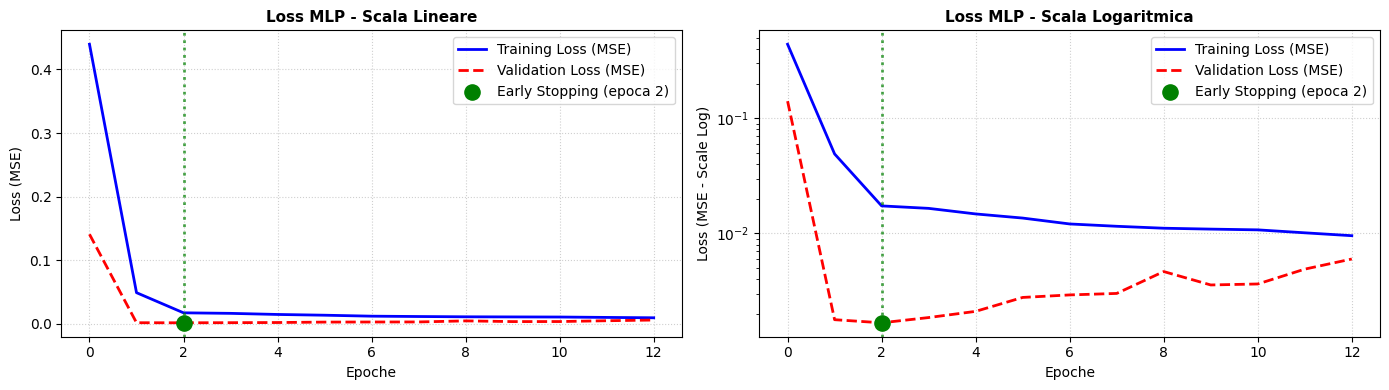

In [8]:
import matplotlib.pyplot as plt
import numpy as np

set_seed(42)  #fisso generatori causali per riproducibilità del modello

print("MLP")
model_mlp = PyTorchMLP() #creo instanza classe MLP

# Training e Validation: RESTITUISCE DIZ HISTORY CON LOS,VAL_LOSS,BEST_EPOCH E MLP CON PESI MIGLIORI
history_mlp, trained_mlp = train_and_validate(
    model_mlp, train_loader, val_loader, epochs=30
)

# Test Evaluation: RESTITUISCE LE METRICHE DI TEST
y_pred_mlp, mse_mlp, rmse_mlp, mae_mlp, mse_pct_mlp, rmse_pct_mlp, mae_pct_mlp = test_loop(
    trained_mlp, test_loader, y_test_real, baselines_test
)

# Salvataggio
results["MLP"] = {
    "pred": y_pred_mlp,
    "mse": mse_mlp,
    "rmse": rmse_mlp,
    "mae": mae_mlp,
    "history": history_mlp,
}

# Stampa Risultati e risultati in %
print(f"Risultati MLP Test Set:")
print(f"  • MSE:  {mse_mlp:.2f} ({mse_pct_mlp:.2f}%)")
print(f"  • RMSE: ${rmse_mlp:.2f}  |  {rmse_pct_mlp:.2f}%")
print(f"  • MAE:  ${mae_mlp:.2f}  |  {mae_pct_mlp:.2f}%")

#GRAFICI LOSS
# UN SOLO PLOT CON EARLY STOPPING
best_epoch = history_mlp.get('best_epoch', 0) #cerca nel diz miglior epoca e restituisce indice,altrimenti da 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4)) #1 riga e2 colonne -> ho 2 grafici ax1 e ax2

# Grafico ax1: Scala Lineare
ax1.plot(history_mlp["loss"], color="blue", label="Training Loss (MSE)", linewidth=2) #curva blu MSE
ax1.plot(history_mlp["val_loss"], color="red", linestyle="--", label="Validation Loss (MSE)", linewidth=2) #curva rossa val_loss

# Grafico early Stopping
if best_epoch > 0:
    ax1.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7) #linea verde verticale : miglior epoca
    ax1.scatter(best_epoch, history_mlp["val_loss"][best_epoch],
               color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})') #punto verde: minimo val_loss

ax1.set_title("Loss MLP - Scala Lineare", fontsize=11, fontweight="bold")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss (MSE)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Grafico ax2: Scala Logaritmica
ax2.plot(history_mlp["loss"], color="blue", label="Training Loss (MSE)", linewidth=2)
ax2.plot(history_mlp["val_loss"], color="red", linestyle="--", label="Validation Loss (MSE)", linewidth=2)

# Early Stopping (scala log)
if best_epoch > 0:
    ax2.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.scatter(best_epoch, history_mlp["val_loss"][best_epoch],
               color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax2.set_yscale("log")
ax2.set_title("Loss MLP - Scala Logaritmica", fontsize=11, fontweight="bold")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Loss (MSE - Scale Log)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

1D-CNN
Risultati 1D-CNN Test Set:
  • MSE:  37.65 (0.18%)
  • RMSE: $6.14  |  4.21%
  • MAE:  $4.14  |  2.84%


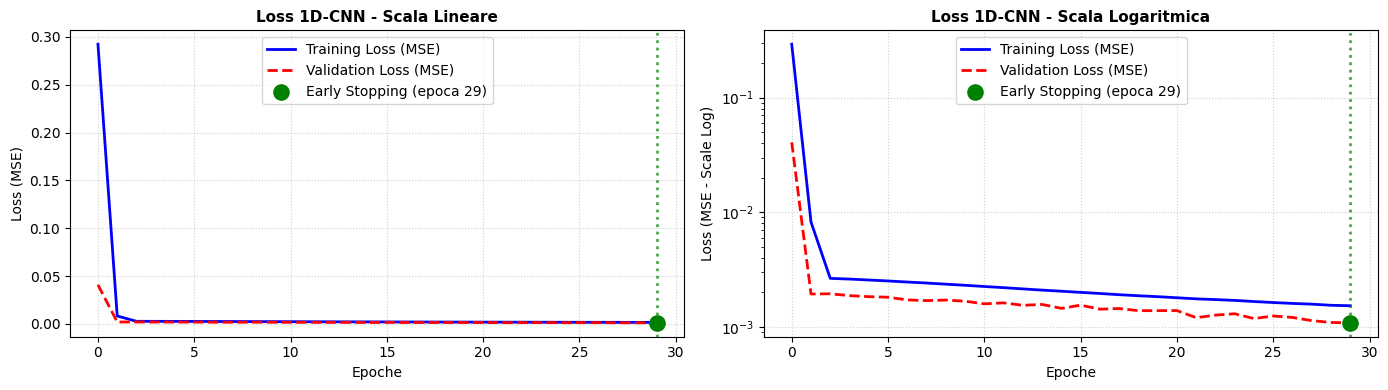

In [9]:
import matplotlib.pyplot as plt

set_seed(42)

print("1D-CNN")
model_cnn = PyTorchCNN1D()

# Training e Validation
history_cnn, trained_cnn = train_and_validate(
    model_cnn, train_loader, val_loader, epochs=30
)



# Test Evaluation
y_pred_cnn, mse_cnn, rmse_cnn, mae_cnn, mse_pct_cnn, rmse_pct_cnn, mae_pct_cnn = test_loop(
    trained_cnn, test_loader, y_test_real, baselines_test
)

# Salvataggio
results["CNN"] = {
    "pred": y_pred_cnn,
    "mse": mse_cnn,
    "rmse": rmse_cnn,
    "mae": mae_cnn,
    "history": history_cnn,
}

# Stampa Risultati Doppi ($ e %)
print(f"Risultati 1D-CNN Test Set:")
print(f"  • MSE:  {mse_cnn:.2f} ({mse_pct_cnn:.2f}%)")
print(f"  • RMSE: ${rmse_cnn:.2f}  |  {rmse_pct_cnn:.2f}%")
print(f"  • MAE:  ${mae_cnn:.2f}  |  {mae_pct_cnn:.2f}%")

# Plot Confronto
best_epoch = history_cnn.get('best_epoch', 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(
    history_cnn["loss"], color="blue", label="Training Loss (MSE)", linewidth=2
)
ax1.plot(
    history_cnn["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax1.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax1.scatter(best_epoch, history_cnn["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax1.set_title(
    "Loss 1D-CNN - Scala Lineare", fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss (MSE)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot(
    history_cnn["loss"], color="blue", label="Training Loss (MSE)", linewidth=2
)
ax2.plot(
    history_cnn["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax2.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.scatter(best_epoch, history_cnn["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax2.set_yscale("log")
ax2.set_title(
    "Loss 1D-CNN - Scala Logaritmica", fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Loss (MSE - Scale Log)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

LSTM
Risultati LSTM Test Set:
  • MSE:  34.78 (0.16%)
  • RMSE: $5.90  |  4.05%
  • MAE:  $4.05  |  2.78%


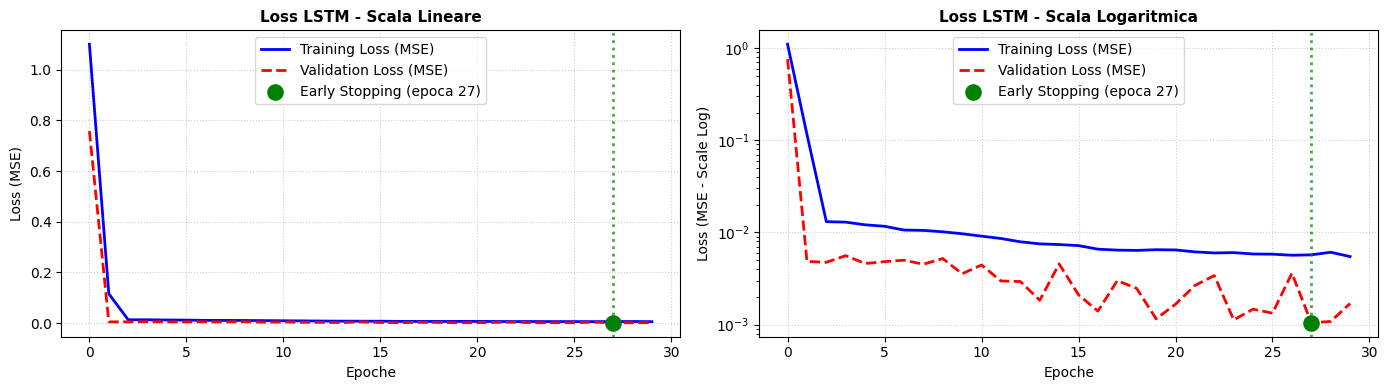

In [10]:
import matplotlib.pyplot as plt

set_seed(42)


print("LSTM")
model_lstm = PyTorchLSTM()

# Training e Validation
history_lstm, trained_lstm = train_and_validate(
    model_lstm, train_loader, val_loader, epochs=30
)



# Test Evaluation
y_pred_lstm, mse_lstm, rmse_lstm, mae_lstm,mse_pct_lstm ,rmse_pct_lstm, mae_pct_lstm = test_loop(
    trained_lstm, test_loader, y_test_real, baselines_test
)

# Salvataggio
results["LSTM"] = {
    "pred": y_pred_lstm,
    "mse": mse_lstm,
    "rmse": rmse_lstm,
    "mae": mae_lstm,
    "history": history_lstm,
}

# Stampa Risultati Doppi ($ e %)
print(f"Risultati LSTM Test Set:")
print(f"  • MSE:  {mse_lstm:.2f} ({mse_pct_lstm:.2f}%)")
print(f"  • RMSE: ${rmse_lstm:.2f}  |  {rmse_pct_lstm:.2f}%")
print(f"  • MAE:  ${mae_lstm:.2f}  |  {mae_pct_lstm:.2f}%")

# Plot Confronto
best_epoch = history_lstm.get('best_epoch', 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(
    history_lstm["loss"],
    color="blue",
    label="Training Loss (MSE)",
    linewidth=2,
)
ax1.plot(
    history_lstm["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax1.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax1.scatter(best_epoch, history_lstm["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax1.set_title(
    "Loss LSTM - Scala Lineare", fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss (MSE)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot(
    history_lstm["loss"],
    color="blue",
    label="Training Loss (MSE)",
    linewidth=2,
)
ax2.plot(
    history_lstm["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax2.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.scatter(best_epoch, history_lstm["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax2.set_yscale("log")
ax2.set_title(
    "Loss LSTM - Scala Logaritmica", fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Loss (MSE - Scale Log)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

GRU
Risultati GRU Test Set:
  • MSE:  21.28 (0.10%)
  • RMSE: $4.61  |  3.17%
  • MAE:  $3.40  |  2.33%


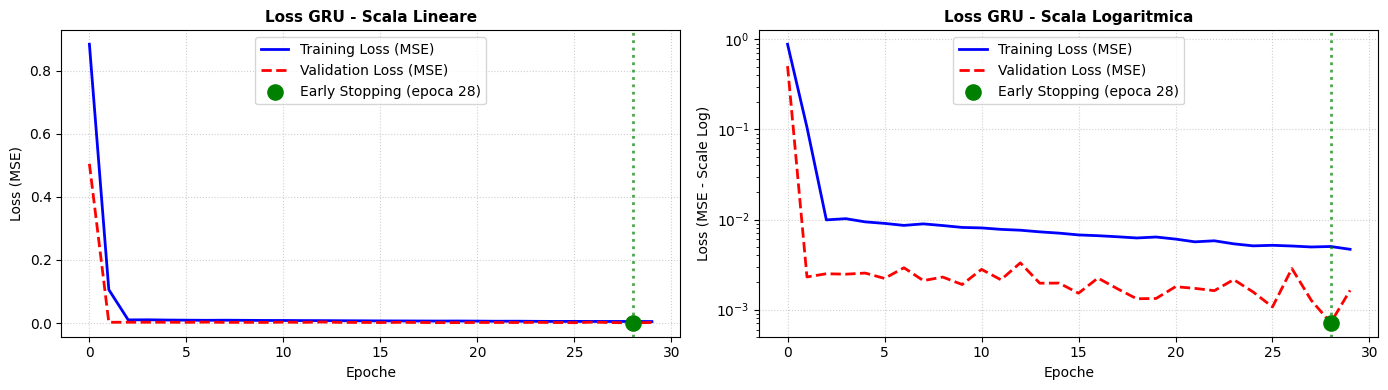

In [11]:
import matplotlib.pyplot as plt

set_seed(42)

print("GRU")
model_gru = PyTorchGRU()

# Training e Validation
history_gru, trained_gru = train_and_validate(
    model_gru, train_loader, val_loader, epochs=30
)



# Test Evaluation
y_pred_gru, mse_gru, rmse_gru, mae_gru, mse_pct_gru, rmse_pct_gru, mae_pct_gru = test_loop(
    trained_gru, test_loader, y_test_real, baselines_test
)

# Salvataggio
results["GRU"] = {
    "pred": y_pred_gru,
    "mse": mse_gru,
    "rmse": rmse_gru,
    "mae": mae_gru,
    "history": history_gru,
}

# Stampa Risultati Doppi ($ e %)
print(f"Risultati GRU Test Set:")
print(f"  • MSE:  {mse_gru:.2f} ({mse_pct_gru:.2f}%)")
print(f"  • RMSE: ${rmse_gru:.2f}  |  {rmse_pct_gru:.2f}%")
print(f"  • MAE:  ${mae_gru:.2f}  |  {mae_pct_gru:.2f}%")

# Plot Confronto
best_epoch = history_gru.get('best_epoch', 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(
    history_gru["loss"], color="blue", label="Training Loss (MSE)", linewidth=2
)
ax1.plot(
    history_gru["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax1.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax1.scatter(best_epoch, history_gru["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax1.set_title(
    "Loss GRU - Scala Lineare", fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss (MSE)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot(
    history_gru["loss"], color="blue", label="Training Loss (MSE)", linewidth=2
)
ax2.plot(
    history_gru["val_loss"],
    color="red",
    linestyle="--",
    label="Validation Loss (MSE)",
    linewidth=2,
)
if best_epoch > 0:
    ax2.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.scatter(best_epoch, history_gru["val_loss"][best_epoch], color='green', s=120, zorder=5, label=f'Early Stopping (epoca {best_epoch})')

ax2.set_yscale("log")
ax2.set_title(
    "Loss GRU - Scala Logaritmica", fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Loss (MSE - Scale Log)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

##  STEP 6: Confronto tra i 4 modelli

Fase finale del progetto in cui testo le capacità predittive del modello su dati mai visti prima:

1. **Tabella e Istrogramma delle metriche**:
   - Genero una tabella e istogramma delle metriche MSE E MAE dei vari modelli per un semplice confronto.

2. **Visualizzazione Grafica del Risultato**:
   - Traccio un grafico finale a linee che mette a confronto visivo e diretto il prezzo reale dell'azione con quello predetto dalle nostre Reti Neurali.

        TABELLA COMPARATIVA METRICHE TEST SET (ORDINATA PER RMSE)


,Modello,RMSE (%),RMSE ($),MAE (%),MAE ($),MSE ($²),MSE (%)
0,GRU,3.17%,4.61 $,2.33%,3.40 $,21.28 $²,0.1003%
1,LSTM,4.05%,5.90 $,2.78%,4.05 $,34.78 $²,0.1639%
2,CNN,4.21%,6.14 $,2.84%,4.14 $,37.65 $²,0.1775%
3,MLP,4.73%,6.89 $,3.24%,4.72 $,47.46 $²,0.2237%


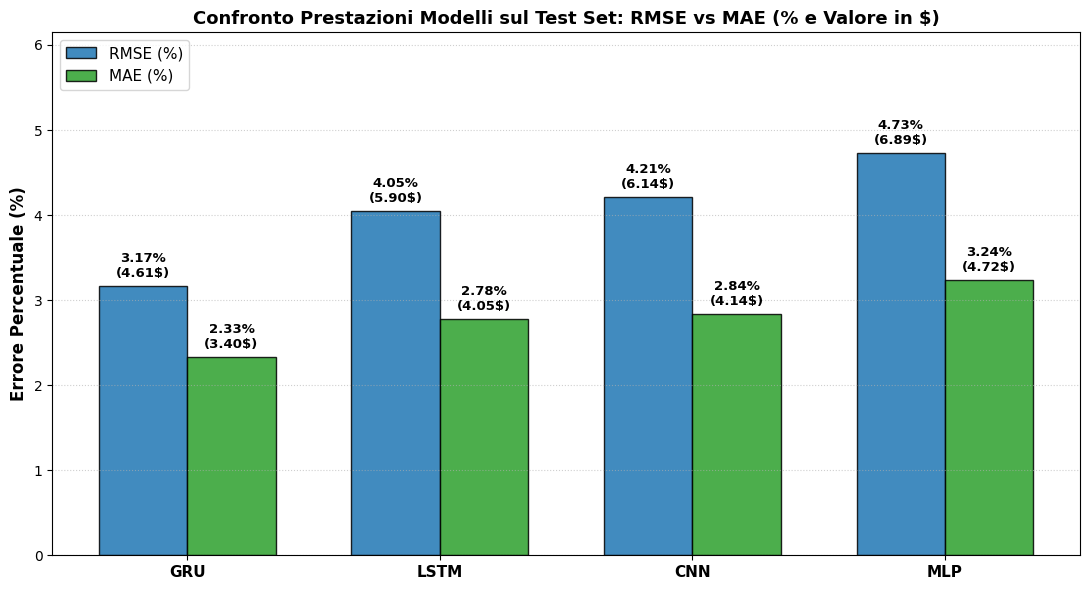

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo del prezzo medio reale sul Test Set
mean_test_price = np.mean(y_test_real)

#lista che raccoglie una riga di metriche per ogni modello
summary_data = []
for model_name, res in results.items():
    mse_val = res['mse']
    rmse_val = res['rmse']
    mae_val = res['mae']

    # Metriche percentuali normalizzate rispetto al prezzo medio
    rmse_pct = (rmse_val / mean_test_price) * 100
    mae_pct = (mae_val / mean_test_price) * 100
    mse_pct = (mse_val / (mean_test_price ** 2)) * 100

    summary_data.append({
        'Modello': model_name,
        'RMSE (%)': rmse_pct,
        'RMSE ($)': rmse_val,
        'MAE (%)': mae_pct,
        'MAE ($)': mae_val,
        'MSE ($²)': mse_val,
        'MSE (%)': mse_pct
    })

# DataFrame di riepilogo(non è quello originale)
#contiene i risultati finali dei 4 modelli
# in ordine dal modello con RMSE più basso (migliore) al più alto
df_confronto = pd.DataFrame(summary_data).sort_values(by='RMSE (%)').reset_index(drop=True)

print("=" * 75)
print("        TABELLA COMPARATIVA METRICHE TEST SET (ORDINATA PER RMSE)")
print("=" * 75)

# Stampa tabella formattata
df_display = df_confronto.copy()
df_display['RMSE (%)'] = df_display['RMSE (%)'].apply(lambda x: f"{x:.2f}%")
df_display['RMSE ($)'] = df_display['RMSE ($)'].apply(lambda x: f"{x:.2f} $")
df_display['MAE (%)']  = df_display['MAE (%)'].apply(lambda x: f"{x:.2f}%")
df_display['MAE ($)']  = df_display['MAE ($)'].apply(lambda x: f"{x:.2f} $")
df_display['MSE ($²)'] = df_display['MSE ($²)'].apply(lambda x: f"{x:.2f} $²")
df_display['MSE (%)']  = df_display['MSE (%)'].apply(lambda x: f"{x:.4f}%")
display(df_display)

# 2. Istogramma a Barre Affiancate: RMSE (%) vs MAE (%) con valore in $ sopra
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(df_confronto))
width = 0.35  # larghezza delle barre

# Barra blu per RMSE, barra verde per MAE
rects1 = ax.bar(x - width/2, df_confronto['RMSE (%)'], width,
                label='RMSE (%)', color='#1f77b4', edgecolor='black', alpha=0.85)
rects2 = ax.bar(x + width/2, df_confronto['MAE (%)'], width,
                label='MAE (%)', color='#2ca02c', edgecolor='black', alpha=0.85)

ax.set_ylabel('Errore Percentuale (%)', fontsize=12, fontweight='bold')
ax.set_title('Confronto Prestazioni Modelli sul Test Set: RMSE vs MAE (% e Valore in $)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_confronto['Modello'], fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Margine superiore per dare spazio alle annotazioni a due righe
max_val = max(df_confronto['RMSE (%)'].max(), df_confronto['MAE (%)'].max())
ax.set_ylim(0, max_val * 1.30)

# Funzione per scrivere sopra ogni barra: "%" alla prima riga e "($)" alla seconda
def aggiungi_etichette(rects, col_pct, col_dollar, unita):
    for rect, pct, dollaro in zip(rects, df_confronto[col_pct], df_confronto[col_dollar]):
        h = rect.get_height()
        ax.annotate(f"{pct:.2f}%\n({dollaro:.2f}{unita})",
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9.5, fontweight='bold')

aggiungi_etichette(rects1, 'RMSE (%)', 'RMSE ($)', '$')
aggiungi_etichette(rects2, 'MAE (%)',  'MAE ($)',  '$')

plt.tight_layout()
plt.show()

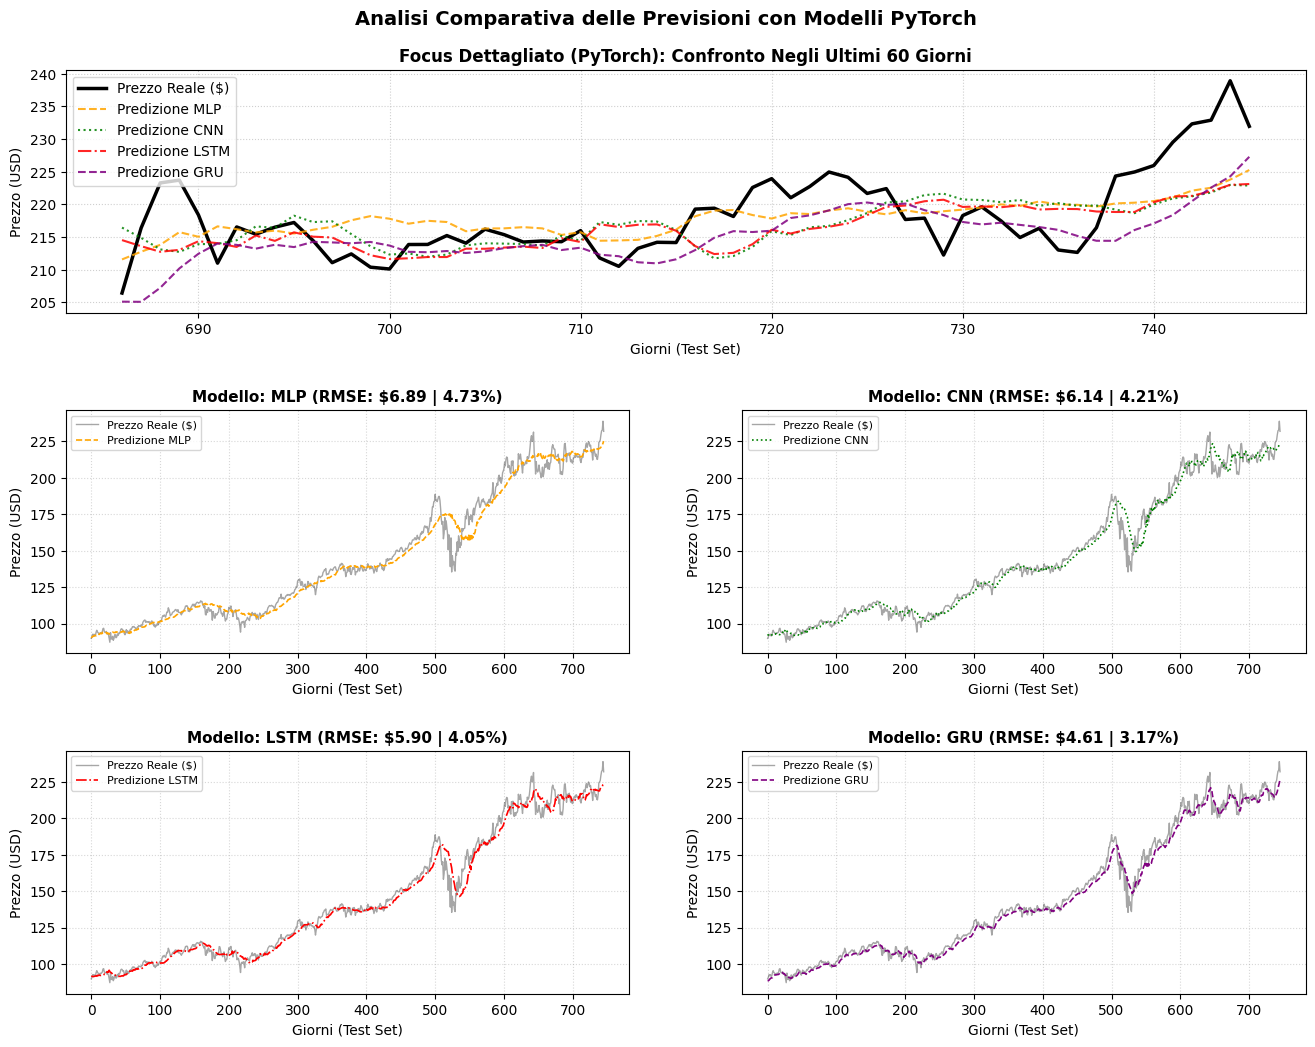

In [13]:

import numpy as np

styles = {
    'MLP': {'color': 'orange', 'linestyle': '--'},
    'CNN': {'color': 'green', 'linestyle': ':'},
    'LSTM': {'color': 'red', 'linestyle': '-.'},
    'GRU': {'color': 'purple', 'linestyle': '--'},
}

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.2) #3 righe e 2 colonne -> ho 5 grafici diversi

# ZOOM ULTIMI 60 GIORNI
ax_zoom = fig.add_subplot(gs[0, :]) #primo subplot comprende riga 0 e tutte colonne
zoom_days = 60 #ultimoi 60 giorni del testset

ax_zoom.plot(
    range(len(y_test_real) - zoom_days, len(y_test_real)),
    y_test_real[-zoom_days:],
    color='black',
    label='Prezzo Reale ($)',
    linewidth=2.5, #piu spessa,curva di riferimento
)

for name, res in results.items(): #agg curve dei 4 modelli
    ax_zoom.plot(
        range(len(res['pred']) - zoom_days, len(res['pred'])),
        res['pred'][-zoom_days:],
        color=styles[name]['color'],
        linestyle=styles[name]['linestyle'],
        label=f'Predizione {name}',
        alpha=0.85,
        linewidth=1.5,
    )

ax_zoom.set_title(
    f'Focus Dettagliato (PyTorch): Confronto Negli Ultimi {zoom_days} Giorni',
    fontsize=12,
    fontweight='bold',
)
ax_zoom.set_xlabel('Giorni (Test Set)')
ax_zoom.set_ylabel('Prezzo (USD)')
ax_zoom.legend(loc='upper left', fontsize=10)
ax_zoom.grid(True, linestyle=':', alpha=0.6)

# CICLO DEI 4 SUBPLOTS INDIVIDUALI
for idx, (name, res) in enumerate(results.items()):
    #indicano posizione  in fig; es. seconda riga,sinistra
    row = 1 + (idx // 2)
    col = idx % 2
    ax = fig.add_subplot(gs[row, col])

    # Recupera o calcola l'RMSE % rispetto al prezzo medio
    # se chiave esiste da valore salvato, altrimenti valore di default (lo ricalcola)
    rmse_pct = res.get(
        'rmse_pct', (res['rmse'] / np.mean(y_test_real)) * 100
    )
    #subplot curva reale
    ax.plot(
        y_test_real,
        color='black',
        alpha=0.35, #trasparenza el grafici
        label='Prezzo Reale ($)',
        linewidth=1,
    )
    #subplot curva predetta
    ax.plot(
        res['pred'],
        color=styles[name]['color'],
        linestyle=styles[name]['linestyle'],
        label=f'Predizione {name}',
        linewidth=1.2,
    )

    # TITOLO AGGIORNATO CON $ E %
    ax.set_title(
        f'Modello: {name} (RMSE: ${res["rmse"]:.2f} | {rmse_pct:.2f}%)',
        fontsize=11,
        fontweight='bold',
    )
    ax.set_xlabel('Giorni (Test Set)')
    ax.set_ylabel('Prezzo (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle(
    'Analisi Comparativa delle Previsioni con Modelli PyTorch',
    fontsize=14,
    fontweight='bold',
    y=0.93,
)
plt.show()